# 🔍 W06 — Multi-Level Explainability Analysis

**Objective**: Apply three levels of interpretability to the best models.

- **Level 1**: Global Feature Importance (XGBoost tree-based)
- **Level 2**: Temporal Feature Dynamics (Attention weights)
- **Level 3**: Instance-Level SHAP Explanations
- **Synthesis**: Cross-level comparison

**Models**: ML = XGBoost (correlation, 32 feat), DL = BiLSTM+Attn (AFICv, 16 feat)

**Author**: Fatima Khadija Benzine — March 2026

---
## 0. Setup

In [1]:
import os
if not os.path.exists('/content/PhD-Project-'):
    !git clone https://github.com/f-khadija-benzine/PhD-Project-.git /content/PhD-Project-
!pip install xgboost shap -q
os.chdir('/content/PhD-Project-/src')

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
from datetime import datetime
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import json, time

project_root = Path('/content/PhD-Project-')
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M')
SAVE_DIR = f'/content/drive/MyDrive/PhD_results/W06_{TIMESTAMP}'
os.makedirs(SAVE_DIR, exist_ok=True)

from data_loader import MultiDatasetLoader
from preprocessing import DataNormalizer, create_sliding_windows, evaluate_per_unit
from bi_fusion import BIFusionPipeline, CONTINUOUS_BI_VARS
from feature_selection import BIAwareFeatureSelector
from feature_selection_aficv import AFICvFeatureSelector
from ml_branch import MLBranch
from attention import build_dual_attention_bilstm
from explainability import (
    get_tree_importance, plot_tree_importance,
    analyze_attention_temporal, plot_attention_heatmap,
    compute_shap_values, aggregate_shap_to_original,
    plot_shap_summary, plot_shap_waterfall, plot_shap_unit_evolution,
    compare_importance_levels,
)
import tensorflow as tf

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print(f"GPU: {tf.config.list_physical_devices('GPU')}")
print(f"Save: {SAVE_DIR}")
print("All imports ✓")

Cloning into '/content/PhD-Project-'...
remote: Enumerating objects: 298, done.
remote: Counting objects: 100% (298/298), done.
remote: Compressing objects: 100% (238/238), done.
remote: Total 298 (delta 140), reused 177 (delta 53), pack-reused 0 (from 0)
Receiving objects: 100% (298/298), 5.18 MiB | 6.62 MiB/s, done.
Resolving deltas: 100% (140/140), done.
Mounted at /content/drive
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Save: /content/drive/MyDrive/PhD_results/W06_20260316_0147
All imports ✓


---
## 1. Load Data + Best Models

In [2]:
DATASET = 'FD001'
W = 30
PAD = False

# Load & preprocess (same as W05)
loader = MultiDatasetLoader()
ds = loader.load_cmapss_dataset(DATASET)
meta_cols = ['unit', 'cycle', 'rul']
train_raw = ds['train'].copy()
test_raw = ds['test'].copy()
train_raw['rul'] = train_raw['rul'].clip(upper=125)
if 'rul' in test_raw.columns:
    test_raw['rul'] = test_raw['rul'].clip(upper=125)

sensor_cols = [c for c in train_raw.columns if c.startswith('sensor_')]
setting_cols = [c for c in train_raw.columns if c.startswith('setting_')]

norm = DataNormalizer(method='minmax')
train_norm = norm.fit_transform(train_raw, sensor_cols + setting_cols)
test_norm = norm.transform(test_raw)

fusion = BIFusionPipeline()
train_fused = fusion.fuse(train_norm, DATASET, split='train', encode_categoricals=True)
test_fused = fusion.fuse(test_norm, DATASET, split='test', encode_categoricals=True)
bi_cols = fusion.get_bi_columns(train_fused)
bi_cont = [c for c in CONTINUOUS_BI_VARS if c in train_fused.columns]
bi_norm = DataNormalizer(method='minmax')
train_fused = bi_norm.fit_transform(train_fused, bi_cont)
test_fused = bi_norm.transform(test_fused)

# Correlation features (for ML branch)
sel_corr = BIAwareFeatureSelector(variance_threshold=0.01, correlation_threshold=0.95)
fn_corr = sel_corr.select_features(data=train_fused, sensor_cols=sensor_cols,
    bi_cols=bi_cols, setting_cols=setting_cols, exclude_cols=meta_cols)
tr_corr = sel_corr.transform(train_fused, keep_cols=meta_cols)
te_corr = sel_corr.transform(test_fused, keep_cols=meta_cols)
X_train_corr, y_train_corr = create_sliding_windows(tr_corr, W, fn_corr, 'rul', pad=PAD)
X_test_corr, y_test_corr = create_sliding_windows(te_corr, W, fn_corr, 'rul', pad=PAD)

# AFICv features (for DL branch)
sel_aficv = AFICvFeatureSelector(base_learner='xgboost', n_folds=5, cumulative_threshold=0.90)
fn_aficv = sel_aficv.select_features_stratified(data=train_fused, sensor_cols=sensor_cols,
    bi_cols=bi_cols, setting_cols=setting_cols, target_col='rul', group_col='unit')
tr_aficv = sel_aficv.transform(train_fused, keep_cols=meta_cols)
te_aficv = sel_aficv.transform(test_fused, keep_cols=meta_cols)
X_train_aficv, y_train_aficv = create_sliding_windows(tr_aficv, W, fn_aficv, 'rul', pad=PAD)
X_test_aficv, y_test_aficv = create_sliding_windows(te_aficv, W, fn_aficv, 'rul', pad=PAD)

print(f"Correlation: {len(fn_corr)} features, train={X_train_corr.shape}")
print(f"AFICv:       {len(fn_aficv)} features, train={X_train_aficv.shape}")

Loading FD001 dataset...
  Files: train=True, test=True, rul=True
  - Training data shape: (20631, 26)
  - Training units: 100
  - Training RUL range: [0, 361]
  - Test data shape: (13096, 26)
  - RUL values shape: (100, 1)
  - Test units found: 100 (units: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]...)
  - RUL values provided: 100
    Unit 1: max_cycle=31, base_RUL=112
    Unit 2: max_cycle=49, base_RUL=98
    Unit 3: max_cycle=126, base_RUL=69
✓ FD001 loaded: 20631 train, 13096 test samples

=== BI Fusion: FD001 (train) ===
  Sensor data: (20631, 27)
  BI data loaded: 20631 rows, 100 units
  Fused data: (20631, 44)
  Features: 21 sensor + 17 BI

=== BI Fusion: FD001 (test) ===
  Sensor data: (13096, 27)
  BI data loaded: 20648 rows, 100 units
  Fused data: (13096, 44)
  Features: 21 sensor + 17 BI

=== BI-Aware Feature Selection ===
  Input: 21 sensor + 17 BI + 3 setting = 41 total
  Variance filter (sensor/settings only):
    Removed 9: ['sensor_1', 'sensor_5'

In [3]:
# Load best params from W05
RESULTS_W05 = '/content/drive/MyDrive/PhD_results/W05_20260303_0304'

with open(f'{RESULTS_W05}/A2_ml_grid_best_20260303_0304.json', 'r') as f:
    ml_saved = json.load(f)
with open(f'{RESULTS_W05}/B2_dl_grid_best_20260303_0304.json', 'r') as f:
    dl_saved = json.load(f)

best_ml = ml_saved['params']
best_dl = dl_saved['params']

print(f"ML: {best_ml}")
print(f"DL: {best_dl}")

ML: {'n_estimators': 500, 'max_depth': 8, 'learning_rate_xgb': 0.05, 'flatten_strategy': 'statistics', 'feature_selection': 'correlation'}
DL: {'lstm_units': 64, 'feature_attention_dim': 32, 'temporal_attention_dim': 64, 'dropout_rate': 0.3, 'dense_units': 64, 'learning_rate': 0.001, 'batch_size': 128, 'feature_selection': 'aficv'}


In [4]:
# Train ML branch (XGBoost, correlation)
ml_model = MLBranch(model_type='xgboost',
    flatten_strategy=best_ml['flatten_strategy'],
    n_estimators=best_ml['n_estimators'],
    max_depth=best_ml['max_depth'],
    learning_rate=best_ml['learning_rate_xgb'])
ml_model.fit(X_train_corr, y_train_corr, feature_names=fn_corr)
print("ML trained ✓")

# Train DL branch (BiLSTM+Attn, AFICv)
tf.keras.backend.clear_session()
dl_model, attn_model = build_dual_attention_bilstm(
    window_size=W, n_features=len(fn_aficv),
    lstm_units=best_dl['lstm_units'],
    feature_attention_dim=best_dl['feature_attention_dim'],
    temporal_attention_dim=best_dl['temporal_attention_dim'],
    dropout_rate=best_dl['dropout_rate'],
    dense_units=best_dl['dense_units'],
    learning_rate=best_dl['learning_rate'])

dl_model.fit(X_train_aficv, y_train_aficv,
    epochs=100, batch_size=best_dl['batch_size'], validation_split=0.2,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)],
    verbose=1)
print("DL trained ✓")


[ML Branch] xgboost — statistics
  Input: (17731, 30, 32) → Flattened: (17731, 192)
  Training complete ✓
ML trained ✓
Epoch 1/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 4062.2812 - mae: 53.1240 - val_loss: 1809.9708 - val_mae: 38.4086 - learning_rate: 0.0010
Epoch 2/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1840.8439 - mae: 37.6695 - val_loss: 1810.4332 - val_mae: 38.4363 - learning_rate: 0.0010
Epoch 3/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1827.4652 - mae: 37.5717 - val_loss: 1740.1460 - val_mae: 37.3122 - learning_rate: 0.0010
Epoch 4/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1147.0924 - mae: 27.9894 - val_loss: 386.8174 - val_mae: 15.4401 - learning_rate: 0.0010
Epoch 5/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 340.4209 - mae: 14.3739 - val_loss: 307.9756 - val_mae: 13.5262 - learning_rate: 0.0010
Epoch 6/100
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 294.7401 - mae: 13.2611 - val_loss: 264.0879 - val_mae: 12.33

---
## 2. Level 1 — Global Feature Importance (Tree-Based)

In [5]:
tree_imp = get_tree_importance(ml_model, fn_corr, top_k=20)
print("=== Global Feature Importance (XGBoost) ===")
print(tree_imp.to_string(index=False))

# Count BI vs sensor in top features
n_bi = (tree_imp['category'] == 'bi').sum()
n_sensor = (tree_imp['category'] == 'sensor').sum()
print(f"\nTop 20: {n_sensor} sensor, {n_bi} BI features")

=== Global Feature Importance (XGBoost) ===
                feature  importance category
       downtime_penalty    0.793408       bi
  spare_parts_available    0.025201       bi
                cm_cost    0.019513       bi
   technician_available    0.019207       bi
  spare_parts_lead_time    0.018409       bi
              sensor_11    0.014555   sensor
                pm_cost    0.012413       bi
       revenue_per_hour    0.011438       bi
               sensor_4    0.009836   sensor
    labor_rate_standard    0.009706       bi
contract_penalty_active    0.009452       bi
    labor_rate_overtime    0.007903       bi
              sensor_20    0.007421   sensor
               sensor_7    0.006754   sensor
              sensor_12    0.006509   sensor
               sensor_2    0.006449   sensor
              sensor_21    0.006044   sensor
               sensor_8    0.005486   sensor
              sensor_15    0.005353   sensor
              sensor_17    0.004943   sensor

Top 20: 10

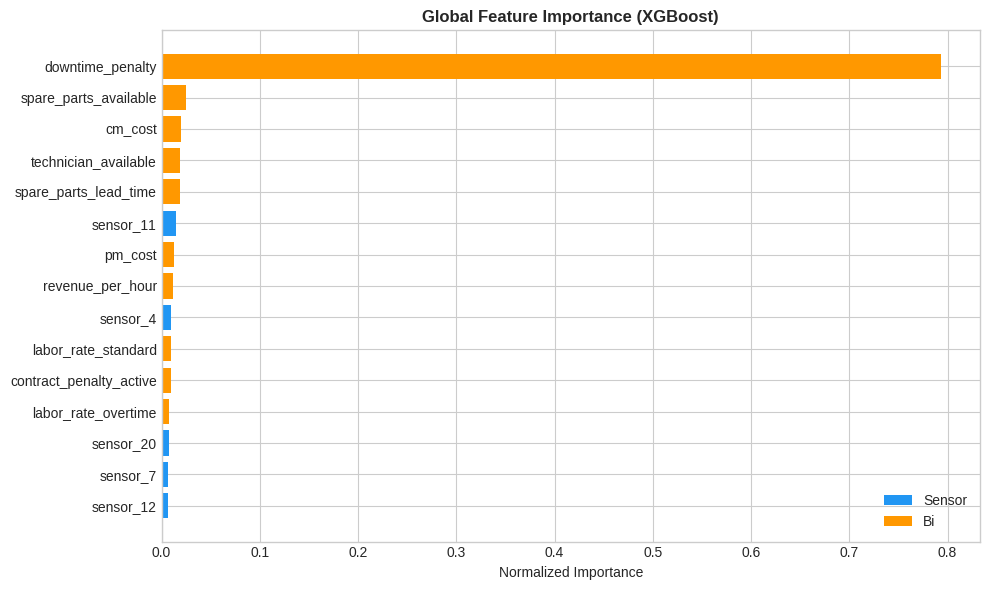

In [31]:
plot_tree_importance(tree_imp.head(15),
    save_path=f'{SAVE_DIR}/level1_tree_importance_{TIMESTAMP}.png')
plt.close()

---
## 3. Level 2 — Temporal Feature Dynamics (Attention)

In [7]:
outputs = attn_model.predict(X_test_aficv[:5], batch_size=5, verbose=0)
print(type(outputs))
if isinstance(outputs, dict):
    print(outputs.keys())
elif isinstance(outputs, list):
    print(f"List of {len(outputs)} elements")
    for i, o in enumerate(outputs):
        print(f"  [{i}] shape={o.shape}")

<class 'dict'>
dict_keys(['rul', 'feature_weights', 'temporal_weights'])


In [11]:
outputs = attn_model.predict(X_test_aficv, batch_size=256, verbose=0)

fw = outputs['feature_weights']   # (samples, timesteps, features)
tw = outputs['temporal_weights']  # (samples, timesteps)

attn_result = {
    'feature_weights': fw,
    'temporal_weights': tw,
    'feature_names': fn_aficv,
    'mean_feature_weights': np.mean(fw, axis=(0, 1)),  # average over samples AND timesteps → (features,)
    'mean_temporal_weights': np.mean(tw, axis=0),       # average over samples → (timesteps,)
}

print(f"Feature weights: {fw.shape} → mean: {attn_result['mean_feature_weights'].shape}")
print(f"Temporal weights: {tw.shape} → mean: {attn_result['mean_temporal_weights'].shape}")

print("\n=== Mean Feature Attention Weights ===")
for i, (name, weight) in enumerate(
    sorted(zip(fn_aficv, attn_result['mean_feature_weights']),
           key=lambda x: -x[1])):
    cat = 'BI' if not name.startswith('sensor') and not name.startswith('setting') else 'Sensor'
    print(f"  {i+1:2d}. {name:25s} {weight:.4f}  [{cat}]")

Feature weights: (10196, 30, 16) → mean: (16,)
Temporal weights: (10196, 30) → mean: (30,)

=== Mean Feature Attention Weights ===
   1. downtime_penalty          0.3589  [BI]
   2. sensor_7                  0.2624  [Sensor]
   3. sensor_17                 0.0900  [Sensor]
   4. sensor_12                 0.0504  [Sensor]
   5. revenue_per_hour          0.0351  [BI]
   6. sensor_11                 0.0324  [Sensor]
   7. technician_available      0.0312  [BI]
   8. sensor_9                  0.0288  [Sensor]
   9. labor_rate_standard       0.0254  [BI]
  10. spare_parts_lead_time     0.0214  [BI]
  11. sensor_4                  0.0170  [Sensor]
  12. spare_parts_available     0.0129  [BI]
  13. cm_cost                   0.0112  [BI]
  14. sensor_20                 0.0102  [Sensor]
  15. labor_rate_overtime       0.0080  [BI]
  16. sensor_15                 0.0045  [Sensor]


In [10]:
print(f"feature_weights shape: {attn_result['feature_weights'].shape}")
print(f"mean_feature_weights shape: {attn_result['mean_feature_weights'].shape}")

feature_weights shape: (10196, 30, 16)
mean_feature_weights shape: (30, 16)


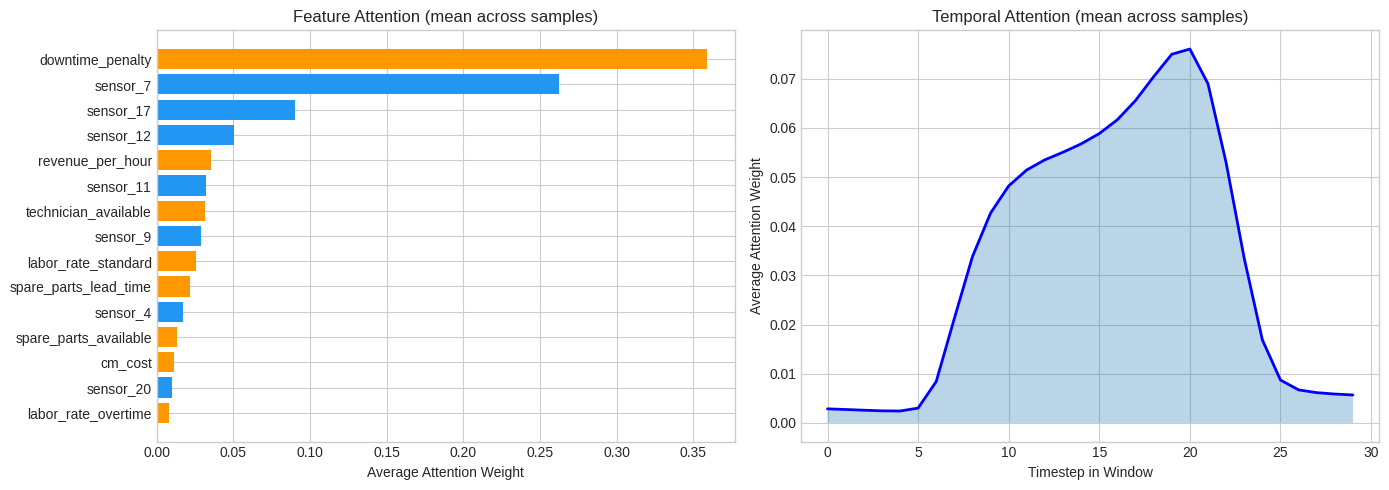

In [32]:
plot_attention_heatmap(attn_result,
    save_path=f'{SAVE_DIR}/level2_attention_weights_{TIMESTAMP}.png')
plt.close()

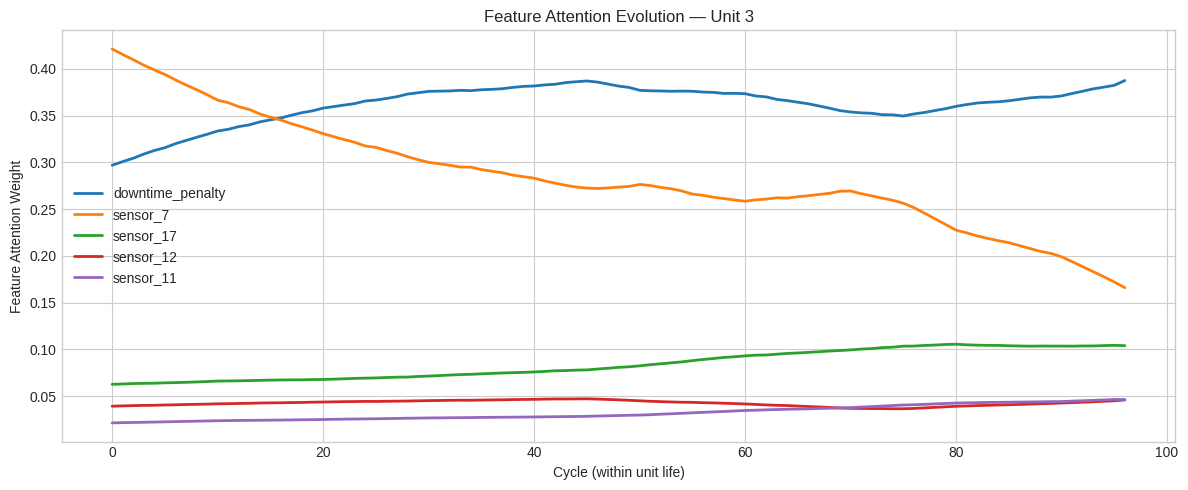

In [33]:
# Temporal evolution of feature attention for unit 1
unit_id = 3
T = len(te_aficv[te_aficv['unit'] == unit_id])
n_win = max(T - (W - 1), 0)

# Get start index for this unit
start = 0
for u in sorted(te_aficv['unit'].unique()):
    if u == unit_id:
        break
    T_u = len(te_aficv[te_aficv['unit'] == u])
    start += max(T_u - (W - 1), 0)

unit_fw = attn_result['feature_weights'][start:start+n_win]  # (n_win, 30, 16)
# Average over the window dimension → (n_win, 16) = feature importance at each cycle
unit_fw_avg = np.mean(unit_fw, axis=1)

# Plot top 5 features over the unit's life
top5 = np.argsort(np.mean(unit_fw_avg, axis=0))[::-1][:5]

fig, ax = plt.subplots(figsize=(12, 5))
for idx in top5:
    ax.plot(range(n_win), unit_fw_avg[:, idx], label=fn_aficv[idx], linewidth=2)
ax.set_xlabel('Cycle (within unit life)')
ax.set_ylabel('Feature Attention Weight')
ax.set_title(f'Feature Attention Evolution — Unit {unit_id}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/level2_attention_evolution_unit{unit_id}_{TIMESTAMP}.png', dpi=150)
plt.show()
plt.close()


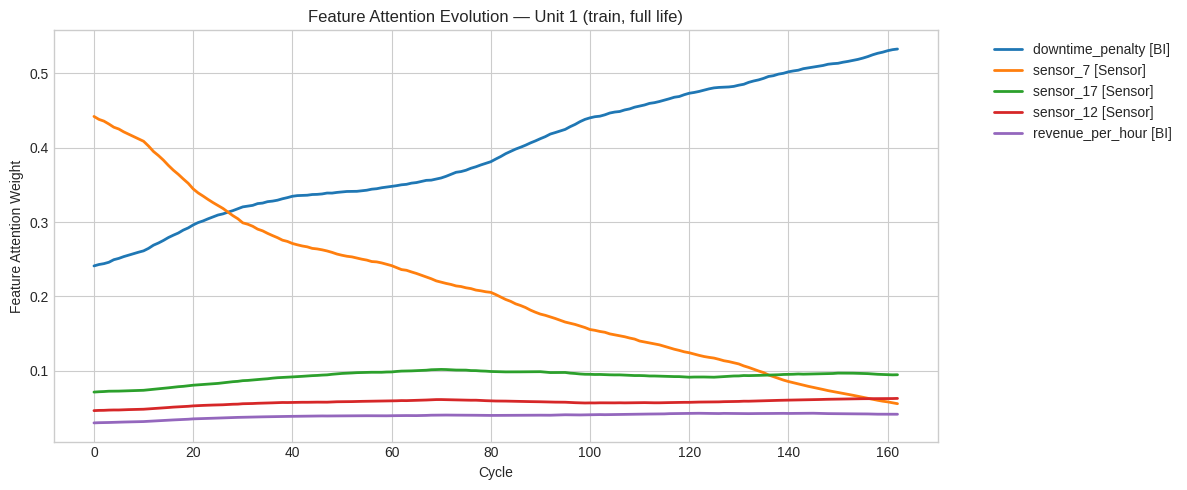

In [18]:
# Sur le train — vie complète jusqu'à la panne
unit_id = 1
T = len(tr_aficv[tr_aficv['unit'] == unit_id])
n_win = max(T - (W - 1), 0)

start = 0
for u in sorted(tr_aficv['unit'].unique()):
    if u == unit_id:
        break
    T_u = len(tr_aficv[tr_aficv['unit'] == u])
    start += max(T_u - (W - 1), 0)

# Predict on train unit
unit_X = X_train_aficv[start:start+n_win]
unit_outputs = attn_model.predict(unit_X, batch_size=256, verbose=0)
unit_fw = unit_outputs['feature_weights']  # (n_win, 30, 16)
unit_fw_avg = np.mean(unit_fw, axis=1)     # (n_win, 16)

top5 = np.argsort(np.mean(unit_fw_avg, axis=0))[::-1][:5]

fig, ax = plt.subplots(figsize=(12, 5))
for idx in top5:
    cat = 'BI' if not fn_aficv[idx].startswith('sensor') and not fn_aficv[idx].startswith('setting') else 'Sensor'
    ax.plot(range(n_win), unit_fw_avg[:, idx], label=f'{fn_aficv[idx]} [{cat}]', linewidth=2)
ax.set_xlabel('Cycle')
ax.set_ylabel('Feature Attention Weight')
ax.set_title(f'Feature Attention Evolution — Unit {unit_id} (train, full life)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/level2_attention_evolution_unit{unit_id}_{TIMESTAMP}.png', dpi=150)
plt.show()
plt.close()

In [20]:
!grep -n "downtime_penalty" /content/PhD-Project-/src/bi_fusion.py | head -20

43:    'downtime_penalty':     {'delta': 10, 'source': 'MES', 'type': 'continuous'},


---
## 4. Level 3 — SHAP Explanations

In [13]:
# Compute SHAP values (takes ~1-2 min)
shap_result = compute_shap_values(ml_model, X_test_corr, fn_corr)
print(f"SHAP values shape: {shap_result['shap_values'].shape}")
print(f"Expected value (baseline): {shap_result['expected_value']:.2f}")

SHAP values shape: (10196, 192)
Expected value (baseline): 80.62


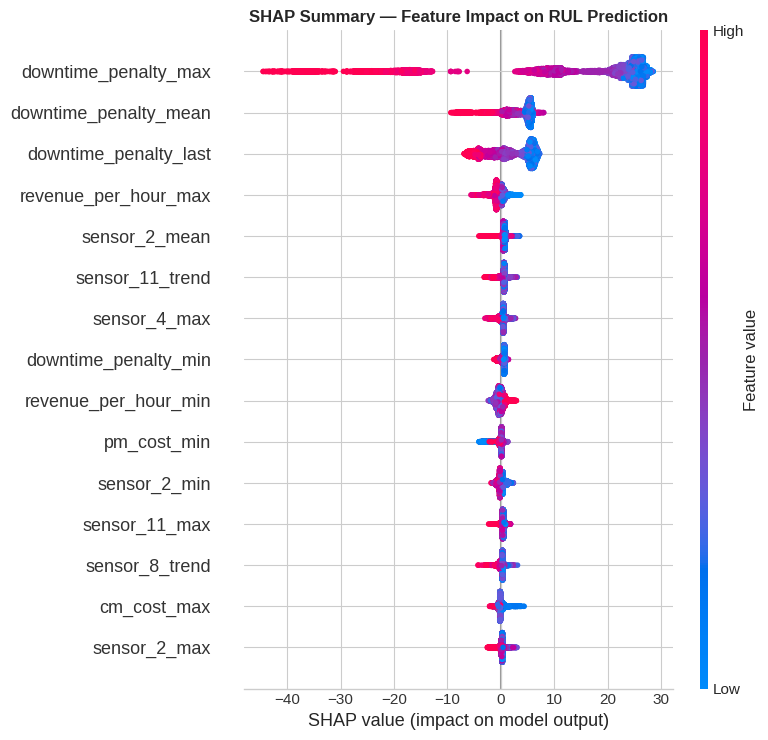

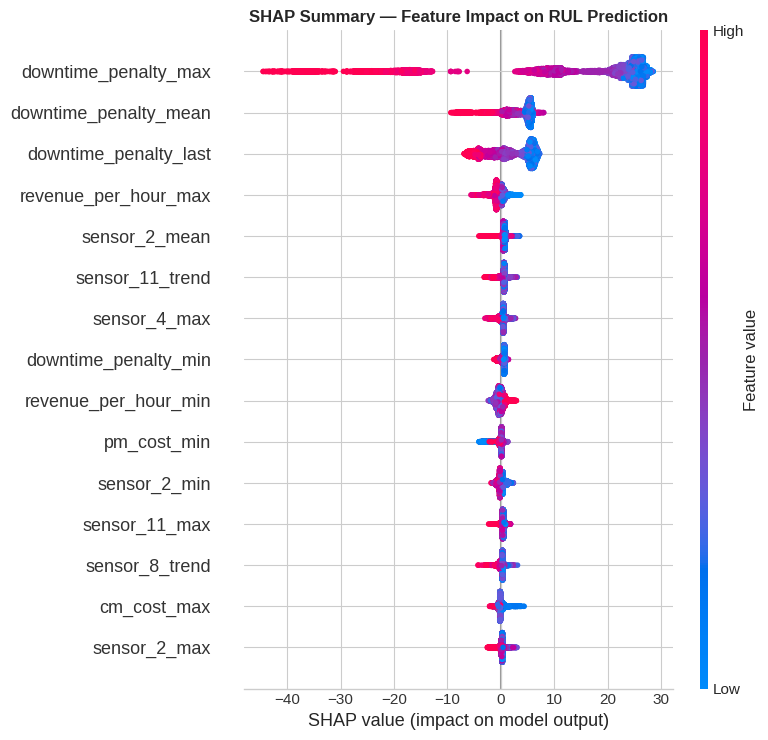

In [14]:
# SHAP Summary plot
plot_shap_summary(shap_result, max_display=15,
    save_path=f'{SAVE_DIR}/level3_shap_summary_{TIMESTAMP}.png')
plt.close()

In [21]:
# Aggregate SHAP to original features
shap_agg = aggregate_shap_to_original(shap_result)
print("=== SHAP Importance (aggregated to original features) ===")
print(shap_agg.head(15).to_string(index=False))

n_bi = (shap_agg.head(15)['category'] == 'bi').sum()
print(f"\nTop 15: {15-n_bi} sensor, {n_bi} BI features")

=== SHAP Importance (aggregated to original features) ===
            feature  mean_abs_shap category
   downtime_penalty      29.583237       bi
   revenue_per_hour       2.018614       bi
           sensor_2       1.807036   sensor
          sensor_11       1.375215   sensor
            pm_cost       1.242370       bi
           sensor_4       1.214701   sensor
            cm_cost       1.049993       bi
labor_rate_standard       0.832955       bi
          sensor_12       0.755890   sensor
           sensor_7       0.704912   sensor
          sensor_15       0.654029   sensor
          sensor_20       0.646890   sensor
           sensor_3       0.625583   sensor
           sensor_8       0.624909   sensor
labor_rate_overtime       0.538014       bi

Top 15: 9 sensor, 6 BI features


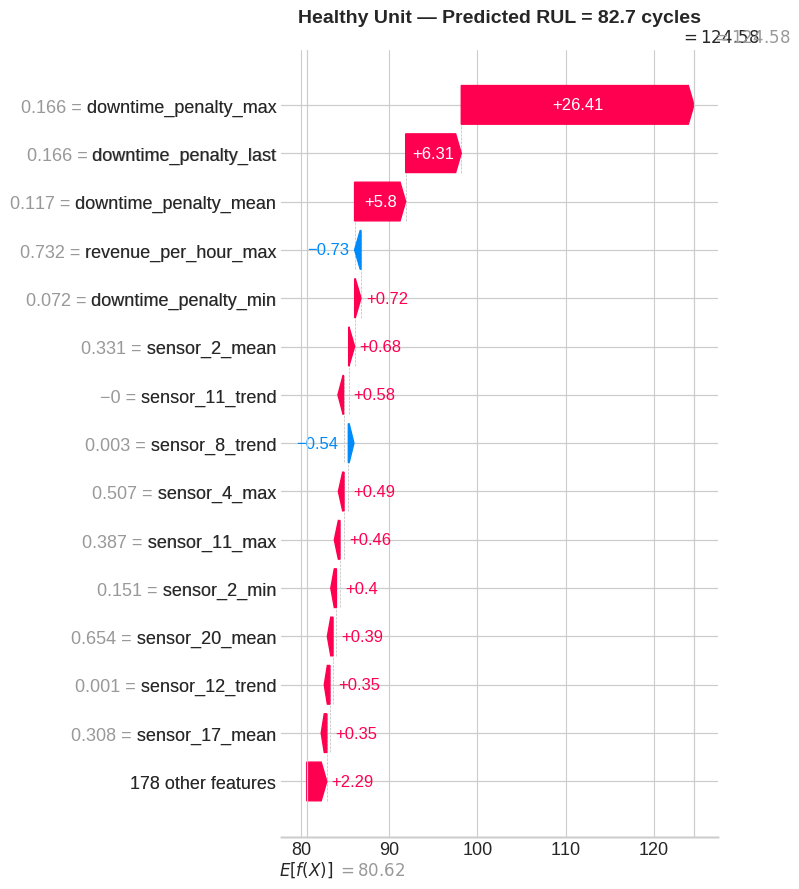

In [38]:
import shap

# Round the values for cleaner display
shap_vals_rounded = np.round(shap_result['shap_values'][0], 2)
x_flat_rounded = np.round(shap_result['X_flat'][0], 3)
base_val_rounded = round(shap_result['expected_value'], 2)

explanation = shap.Explanation(
    values=shap_vals_rounded,
    #base_values=base_val_rounded,
    data=x_flat_rounded,
    feature_names=shap_result['feature_names_flat'],
)

plt.figure(figsize=(10, 10))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/fig_shap_waterfall_healthy.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

Sample 3281: true RUL = 7


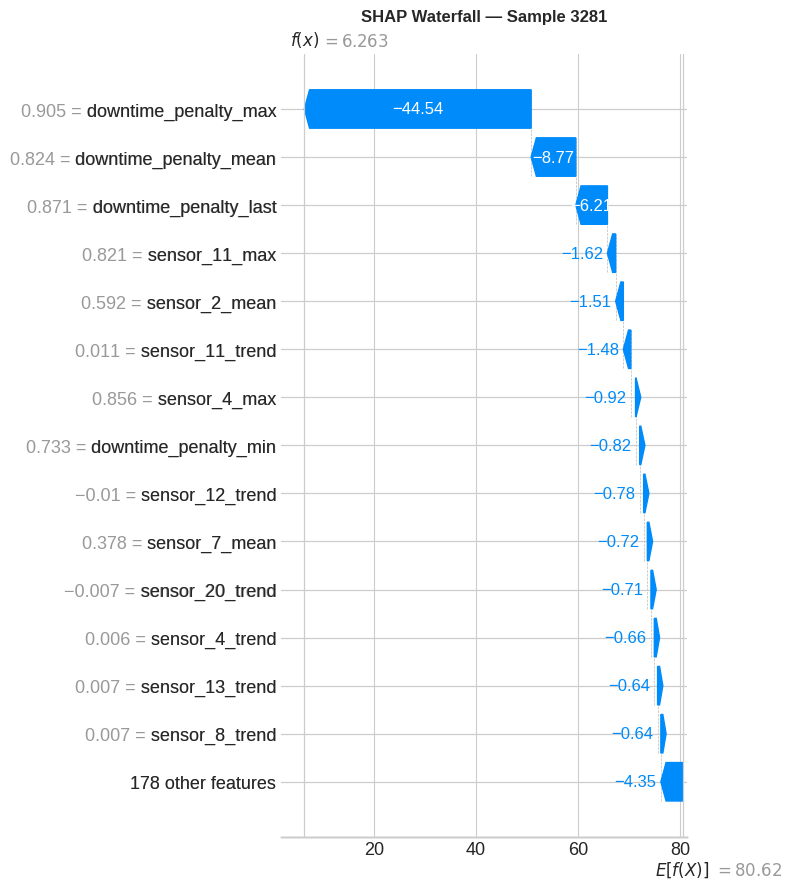

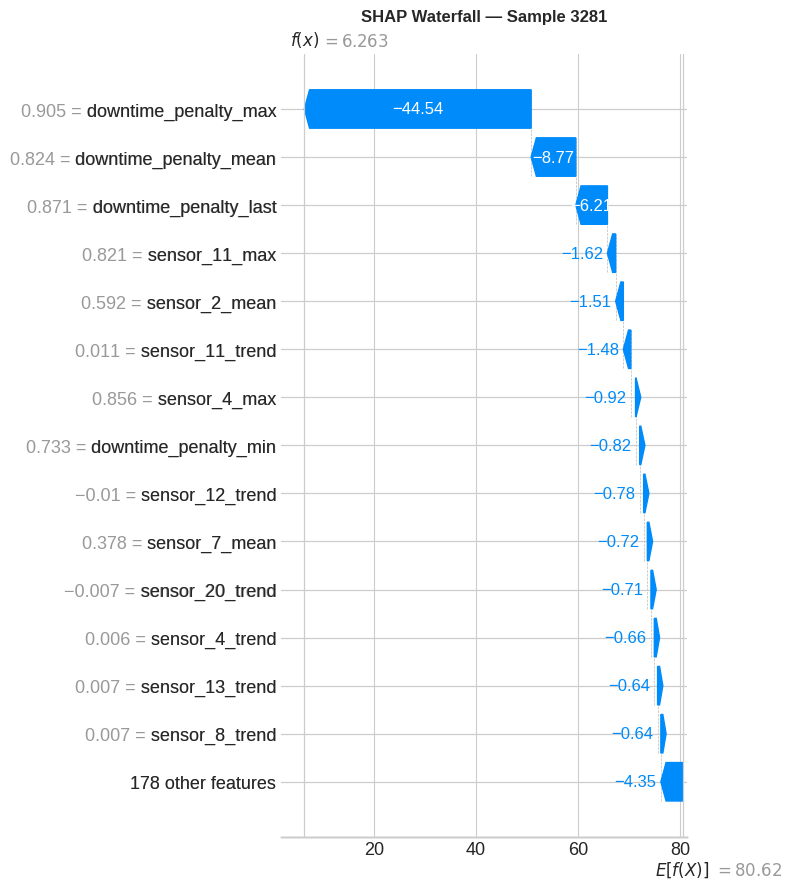

In [23]:
# Waterfall plot for unit near failure (last sample of a unit)
# Find a unit with low true RUL
low_rul_idx = np.argmin(y_test_corr)
print(f"Sample {low_rul_idx}: true RUL = {y_test_corr[low_rul_idx]:.0f}")

plot_shap_waterfall(shap_result, sample_idx=low_rul_idx,
    save_path=f'{SAVE_DIR}/level3_shap_waterfall_critical_{TIMESTAMP}.png')

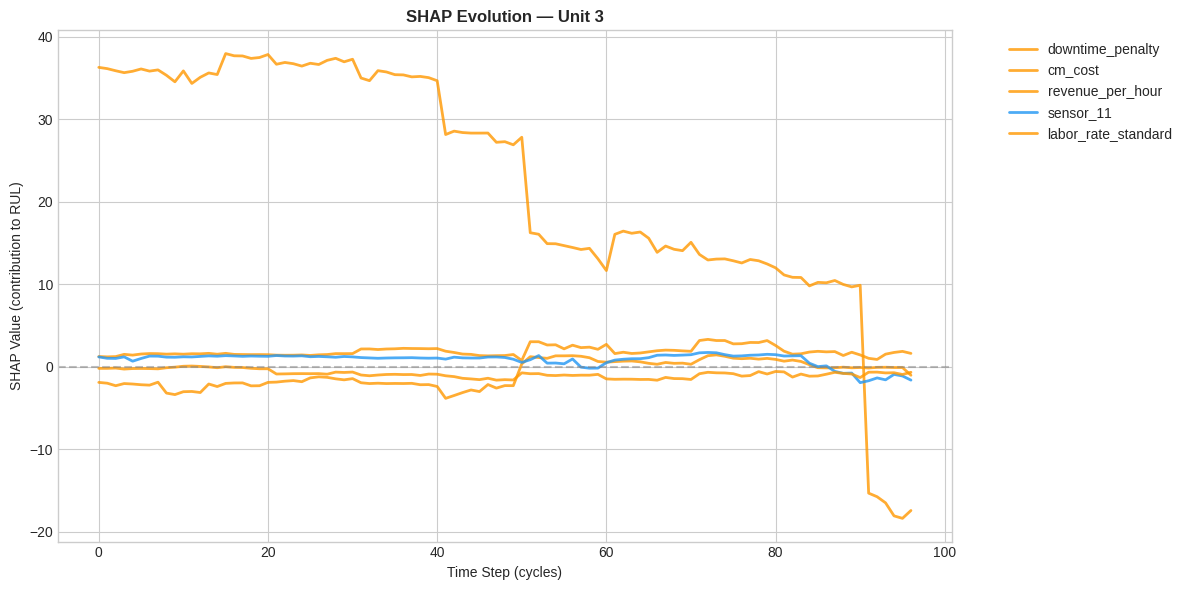

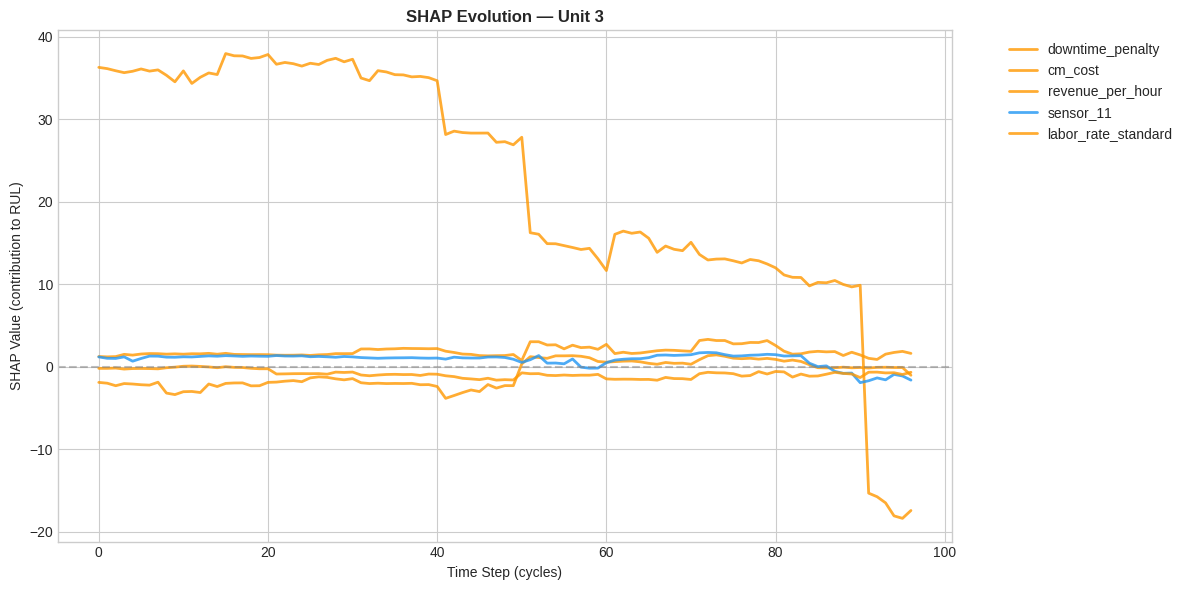

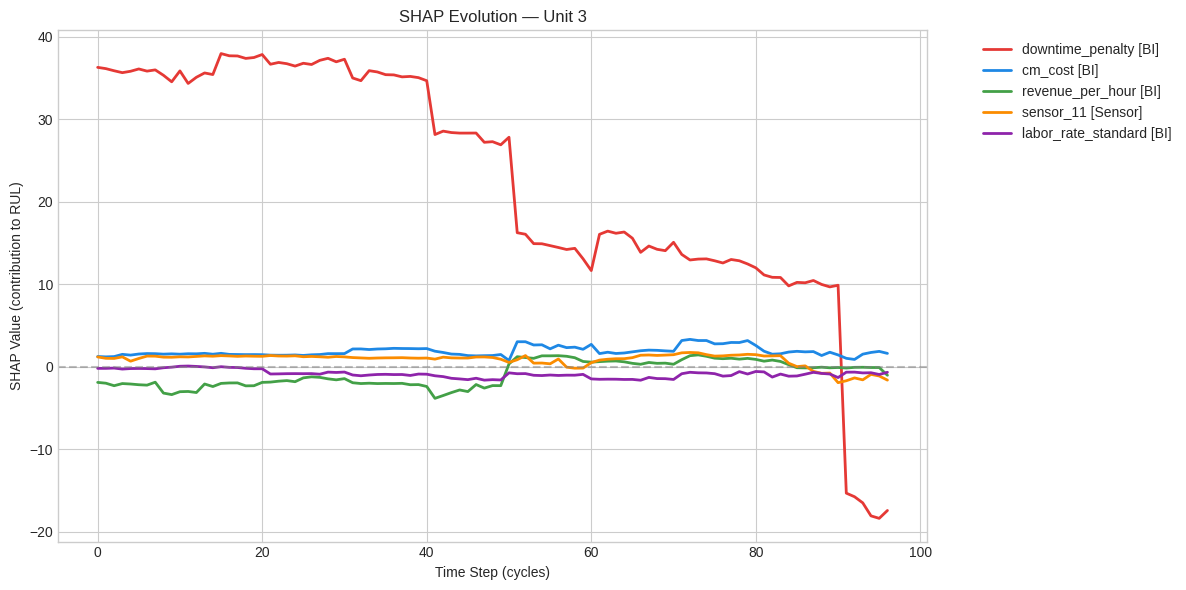

In [30]:
# SHAP evolution with distinct colors
unit_id = 3
start_idx = 0
for u in sorted(te_corr['unit'].unique()):
    if u == unit_id:
        break
    T_u = len(te_corr[te_corr['unit'] == u])
    start_idx += max(T_u - (W - 1), 0)

n_win = max(len(te_corr[te_corr['unit'] == unit_id]) - (W - 1), 0)
unit_shap = shap_result['shap_values'][start_idx:start_idx + n_win]

# Aggregate to original features
agg_shap = np.zeros((n_win, len(fn_corr)))
flat_names = shap_result['feature_names_flat']
for i, flat_name in enumerate(flat_names):
    for j, orig in enumerate(fn_corr):
        if flat_name.startswith(orig + '_'):
            agg_shap[:, j] += unit_shap[:, i]
            break

top5 = np.argsort(np.mean(np.abs(agg_shap), axis=0))[::-1][:5]

colors = ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']
fig, ax = plt.subplots(figsize=(12, 6))
for k, idx in enumerate(top5):
    cat = 'BI' if not fn_corr[idx].startswith('sensor') and not fn_corr[idx].startswith('setting') else 'Sensor'
    ax.plot(range(n_win), agg_shap[:, idx], label=f'{fn_corr[idx]} [{cat}]',
            linewidth=2, color=colors[k])

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time Step (cycles)')
ax.set_ylabel('SHAP Value (contribution to RUL)')
ax.set_title(f'SHAP Evolution — Unit {unit_id}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/level3_shap_evolution_unit{unit_id}_{TIMESTAMP}.png', dpi=150)
plt.show()

---
## 5. Synthesis — Cross-Level Comparison

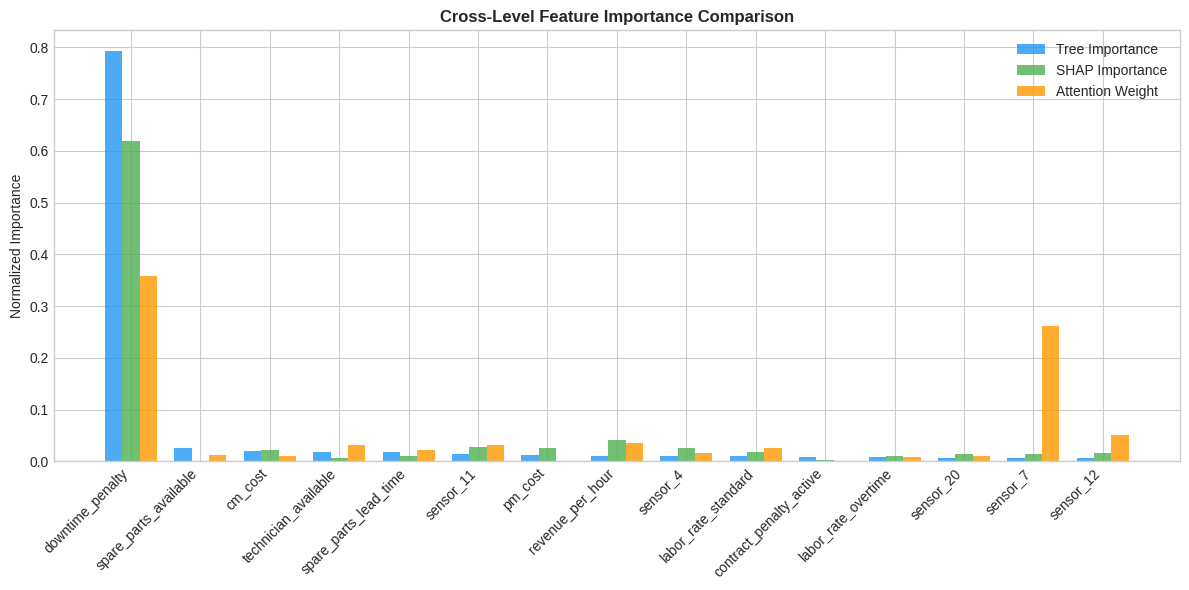


=== Cross-Level Feature Importance ===
                feature  tree_importance category  shap_importance  attention_importance
       downtime_penalty         0.793408       bi         0.619471              0.358946
  spare_parts_available         0.025201       bi         0.001768              0.012946
                cm_cost         0.019513       bi         0.021987              0.011213
   technician_available         0.019207       bi         0.006639              0.031240
  spare_parts_lead_time         0.018409       bi         0.010325              0.021372
              sensor_11         0.014555   sensor         0.028797              0.032360
                pm_cost         0.012413       bi         0.026015              0.000000
       revenue_per_hour         0.011438       bi         0.042270              0.035110
               sensor_4         0.009836   sensor         0.025436              0.017028
    labor_rate_standard         0.009706       bi         0.017442    

In [27]:
# Compare all three levels
# Note: attention uses AFICv features (16), tree/SHAP use correlation (32)
# We compare the features that appear in both sets

comparison = compare_importance_levels(
    tree_imp, shap_agg, attn_result,
    save_path=f'{SAVE_DIR}/synthesis_cross_level_{TIMESTAMP}.png')

print("\n=== Cross-Level Feature Importance ===")
print(comparison.head(15).to_string(index=False))

In [28]:
# Key finding: which BI features appear in top-10 across levels?
print("\n=== BI Features in Top-10 per Level ===")

top10_tree = set(tree_imp.head(10)['feature'])
top10_shap = set(shap_agg.head(10)['feature'])

bi_in_tree = [f for f in top10_tree if not f.startswith('sensor') and not f.startswith('setting')]
bi_in_shap = [f for f in top10_shap if not f.startswith('sensor') and not f.startswith('setting')]

print(f"Tree importance: {bi_in_tree}")
print(f"SHAP importance: {bi_in_shap}")

if attn_result:
    top10_attn = [fn_aficv[i] for i in np.argsort(attn_result['mean_feature_weights'])[::-1][:10]]
    bi_in_attn = [f for f in top10_attn if not f.startswith('sensor') and not f.startswith('setting')]
    print(f"Attention:       {bi_in_attn}")


=== BI Features in Top-10 per Level ===
Tree importance: ['spare_parts_available', 'technician_available', 'pm_cost', 'spare_parts_lead_time', 'revenue_per_hour', 'cm_cost', 'downtime_penalty', 'labor_rate_standard']
SHAP importance: ['pm_cost', 'revenue_per_hour', 'cm_cost', 'downtime_penalty', 'labor_rate_standard']
Attention:       ['downtime_penalty', 'revenue_per_hour', 'technician_available', 'labor_rate_standard', 'spare_parts_lead_time']


In [29]:
# Save all results
tree_imp.to_csv(f'{SAVE_DIR}/level1_tree_importance_{TIMESTAMP}.csv', index=False)
shap_agg.to_csv(f'{SAVE_DIR}/level3_shap_aggregated_{TIMESTAMP}.csv', index=False)
comparison.to_csv(f'{SAVE_DIR}/synthesis_comparison_{TIMESTAMP}.csv', index=False)

print(f"\n✓ All saved to {SAVE_DIR}")


✓ All saved to /content/drive/MyDrive/PhD_results/W06_20260316_0147


---
## Files saved:
```
PhD_results/W06_YYYYMMDD_HHMM/
    level1_tree_importance_*.csv
    level1_tree_importance_*.png
    level2_attention_weights_*.png
    level3_shap_summary_*.png
    level3_shap_waterfall_healthy_*.png
    level3_shap_waterfall_critical_*.png
    level3_shap_evolution_unit1_*.png
    level3_shap_aggregated_*.csv
    synthesis_cross_level_*.png
    synthesis_comparison_*.csv
```